In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob

## Data paths

In [3]:
DATA_DIR = "symbols"  # root folder

real_files = glob(os.path.join(DATA_DIR, "real", "*.csv"))
fake_files = glob(os.path.join(DATA_DIR, "fake", "*.csv"))

print(f"Real samples: {len(real_files)}")
print(f"Fake samples: {len(fake_files)}")

Real samples: 1651
Fake samples: 1651


In [4]:
def load_csv(file_path):
    df = pd.read_csv(file_path, sep="\t")
    df.columns = df.columns.str.strip()
    return df

In [4]:
sample_file = real_files[0]
df = load_csv(sample_file)
df.head()

,stroke_id,x,y,time,is_writing
0,1.0,324.9694,292.1356,0.0,1.0
1,1.0,345.9431,302.1231,10.0,1.0
2,1.0,353.9331,305.1194,20.0,1.0
3,1.0,358.9269,307.1169,30.0,1.0
4,1.0,363.9206,310.1131,40.0,1.0


## Stroke visualization

In [5]:
def plot_symbol(df, title="Symbol"):
    plt.figure(figsize=(4, 4))

    df.columns = df.columns.str.strip().str.lower()

    # Plot only when pen is touching (optional)
    if "is_writing" in df.columns:
        df_plot = df[df["is_writing"] == 1]
    else:
        df_plot = df

    plt.plot(df_plot["x"], df_plot["y"], marker="o", markersize=2)

    # Mark starting point using time == 0
    if "time" in df.columns:
        start_point = df[df["time"] == 0.0]
        if not start_point.empty:
            plt.scatter(start_point["x"], start_point["y"],
                        s=20, label="start")

    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()

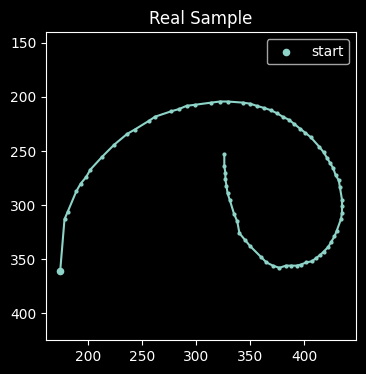

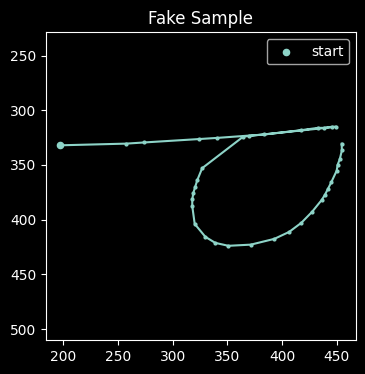

In [6]:
import random

idx = random.randint(0, min(len(real_files), len(fake_files)) - 1)

real_file = real_files[idx]
fake_file = fake_files[idx]

df_real = load_csv(real_file)
plot_symbol(df_real, "Real Sample")

df_fake = load_csv(fake_file)
plot_symbol(df_fake, "Fake Sample")

## Statistics

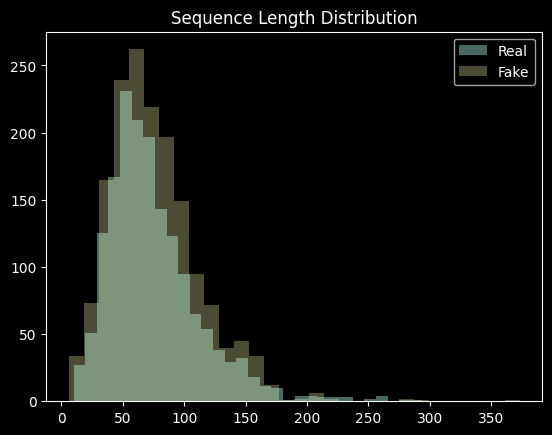

In [7]:
def get_lengths(file_list):
    lengths = []
    for f in file_list:
        df = load_csv(f)
        lengths.append(len(df))
    return lengths

real_lengths = get_lengths(real_files)
fake_lengths = get_lengths(fake_files)

plt.hist(real_lengths, bins=30, alpha=0.5, label="Real")
plt.hist(fake_lengths, bins=30, alpha=0.3, label="Fake")
plt.legend()
plt.title("Sequence Length Distribution")
plt.show()

In [8]:
df = load_csv(real_files[0])
print(df["is_writing"].value_counts())

is_writing
1.0    102
Name: count, dtype: int64


In [9]:
def extract_basic_features(df):
    return {
        "length": len(df),
        "x_mean": df["x"].mean(),
        "y_mean": df["y"].mean(),
        "x_std": df["x"].std(),
        "y_std": df["y"].std(),
    }

features = extract_basic_features(load_csv(real_files[0]))
features

{'length': 102,
 'x_mean': np.float64(393.2662529411764),
 'y_mean': np.float64(418.7222911764706),
 'x_std': np.float64(47.2759635019799),
 'y_std': np.float64(63.62803393175072)}

### Distribution of stroke lengths/speed

Since the resolution of time stamps is always 10, the average length of a stroke is also the average speed of the pen, if you divide by 10ms.

In [10]:
import numpy as np

def compute_path_length(df):
    dx = np.diff(df["x"])
    dy = np.diff(df["y"])
    return np.sum(np.sqrt(dx**2 + dy**2))

def get_lengths(file_list):
    lengths = []
    for f in file_list:
        df = load_csv(f)
        df = df[df["is_writing"] == 1]
        lengths.append(compute_path_length(df) / (len(df)-1) )  # -1 due to np.diff

    return lengths

real_lengths = get_lengths(real_files)
fake_lengths = get_lengths(fake_files)

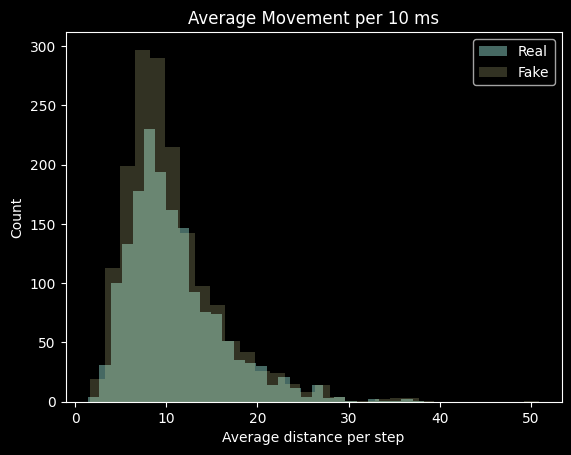

In [11]:
plt.hist(real_lengths, bins=30, alpha=0.5, label="Real")
plt.hist(fake_lengths, bins=30, alpha=0.2, label="Fake")
plt.legend()
plt.title("Average Movement per 10 ms")
plt.xlabel("Average distance per step")
plt.ylabel("Count")
plt.show()

### Only first stroke

Conclusion: It is not necessary only the first segment. Also later segments are longer for fakes.

In [12]:
def first_segment_length(df):
    df = df.reset_index(drop=True)

    # keep only writing points
    df = df[df["is_writing"] == 1].reset_index(drop=True)

    if len(df) < 2:
        return None

    dx = df.loc[1, "x"] - df.loc[0, "x"]
    dy = df.loc[1, "y"] - df.loc[0, "y"]

    return np.sqrt(dx**2 + dy**2)


def get_first_segment_lengths(file_list):
    lengths = []

    for f in file_list:
        df = load_csv(f)
        val = first_segment_length(df)

        if val is not None:
            lengths.append(val)

    return lengths

real_first_seg = get_first_segment_lengths(real_files)
fake_first_seg = get_first_segment_lengths(fake_files)

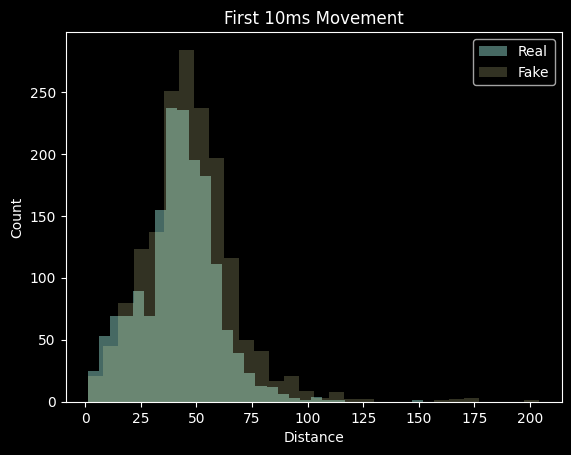

In [13]:
plt.hist(real_first_seg, bins=30, alpha=0.5, label="Real")
plt.hist(fake_first_seg, bins=30, alpha=0.2, label="Fake")
plt.legend()
plt.title("First 10ms Movement")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

### Time pen lifted up

It turned out that the is_writing is always equal to 1. So, we can drop that feature.

In [14]:
def count_is_writing(file_list):
    count_0 = 0
    count_1 = 0

    for f in file_list:
        df = load_csv(f)

        count_0 += (df["is_writing"] == 0).sum()
        count_1 += (df["is_writing"] == 1).sum()

    return count_0, count_1


real_0, real_1 = count_is_writing(real_files)
fake_0, fake_1 = count_is_writing(fake_files)

print("Real   -> 0:", real_0, "| 1:", real_1)
print("Fake   -> 0:", fake_0, "| 1:", fake_1)

Real   -> 0: 0 | 1: 123952
Fake   -> 0: 0 | 1: 125623


### Time deltas

Are they always 10ms?

In [15]:
def check_time_deltas(file_list):
    all_deltas = []

    for f in file_list:
        df = load_csv(f)
        deltas = np.diff(df["time"])
        if len(df[df["stroke_id"] > 1]):
            pass
        #if np.mean(deltas) > 20:
        #    pass
        all_deltas.extend(deltas)

    return np.array(all_deltas)


real_deltas = check_time_deltas(real_files)
fake_deltas = check_time_deltas(fake_files)

In [16]:
print(np.unique(np.round(real_deltas, 3)))
print(np.unique(np.round(fake_deltas, 3)))
print("Real:", np.mean(real_deltas), np.std(real_deltas))
print("Fake:", np.mean(fake_deltas), np.std(fake_deltas))

[ 10.  30. 510.]
[10]
Real: 12.281420429922894 33.6960953364383
Fake: 10.0 0.0


The time deltas of 510, which are a lot, all come from the real ones when we switch from stroke_id 1 to stroke_id 2. Somehow, it's always 510ms. Let's examine this to be suer.

In [17]:
def get_stroke_transition_deltas(file_list):
    deltas = []

    for f in file_list:
        df = load_csv(f)
        df = df.reset_index(drop=True)

        if len(df["stroke_id"].unique()) == 1:
            continue
        elif len(df["stroke_id"].unique()) < 1:
            print("Warning: Please examine. Number of unique stroke ID's is less than 1.")

        for i in range(1, len(df)):
            if df.loc[i, "stroke_id"] != df.loc[i-1, "stroke_id"]:
                dt = df.loc[i, "time"] - df.loc[i-1, "time"]
                deltas.append(dt)

    return deltas


real_transitions = get_stroke_transition_deltas(real_files)
fake_transitions = get_stroke_transition_deltas(fake_files)

In [18]:
real_counts = pd.Series(real_transitions).value_counts().sort_index()
fake_counts = pd.Series(fake_transitions).value_counts().sort_index()

print("Real transitions:")
print(real_counts)

print("\nFake transitions:")
print(fake_counts)

Real transitions:
10.0     128
30.0       1
510.0    558
Name: count, dtype: int64

Fake transitions:
10    664
Name: count, dtype: int64


### Number of strokes per symbol

Nothing to be had here...

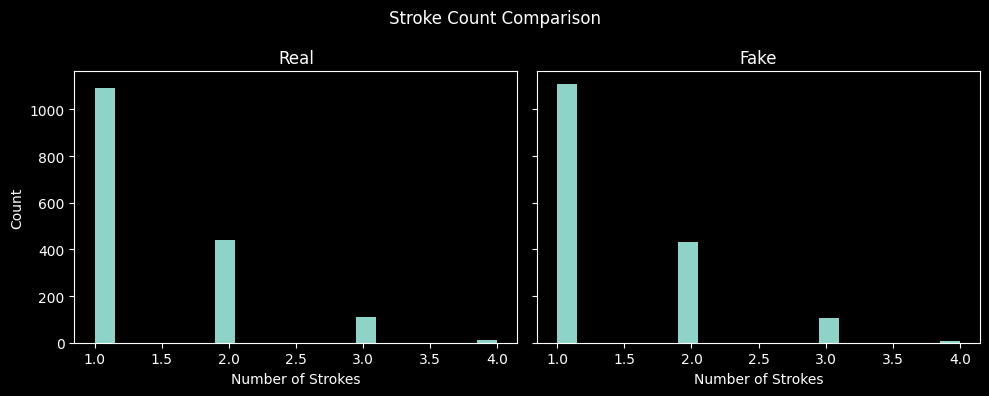

In [19]:
def num_strokes(df):
    return df["stroke_id"].nunique()

real_strokes = [num_strokes(load_csv(f)) for f in real_files]
fake_strokes = [num_strokes(load_csv(f)) for f in fake_files]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Real
axes[0].hist(real_strokes, bins=20)
axes[0].set_title("Real")
axes[0].set_xlabel("Number of Strokes")
axes[0].set_ylabel("Count")

# Fake
axes[1].hist(fake_strokes, bins=20)
axes[1].set_title("Fake")
axes[1].set_xlabel("Number of Strokes")

plt.suptitle("Stroke Count Comparison")
plt.tight_layout()
plt.show()

### Variability of movement

I could imagine that deep fakes have a smaller variance => Hmm, not strong enough.

In [20]:
def movement_std(df):
    dx = np.diff(df["x"])
    dy = np.diff(df["y"])
    dist = np.sqrt(dx**2 + dy**2)
    return np.std(dist)

real_std = [movement_std(load_csv(f)) for f in real_files]
fake_std = [movement_std(load_csv(f)) for f in fake_files]

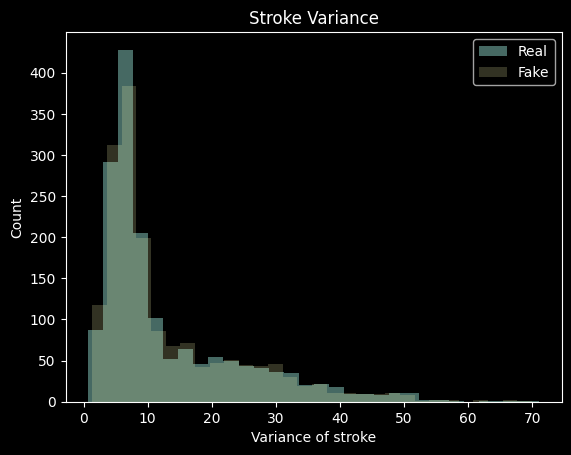

In [21]:
plt.hist(real_std, bins=30, alpha=0.5, label="Real")
plt.hist(fake_std, bins=30, alpha=0.2, label="Fake")
plt.legend()
plt.title("Stroke Variance")
plt.xlabel("Variance of stroke")
plt.ylabel("Count")
plt.show()

### Direction changes

Yes, there is a strong signal, but it is the other way around that I expected. I've expected fake ones to have a lower variability. Still valuable.

In [22]:
def direction_changes(df):
    dx = np.diff(df["x"])
    dy = np.diff(df["y"])
    angles = np.arctan2(dy, dx)

    # compute angle differences
    dtheta = np.diff(angles)

    # fix angle wrapping
    dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi

    return np.std(dtheta)

real_dir = [direction_changes(load_csv(f)) for f in real_files]
fake_dir = [direction_changes(load_csv(f)) for f in fake_files]

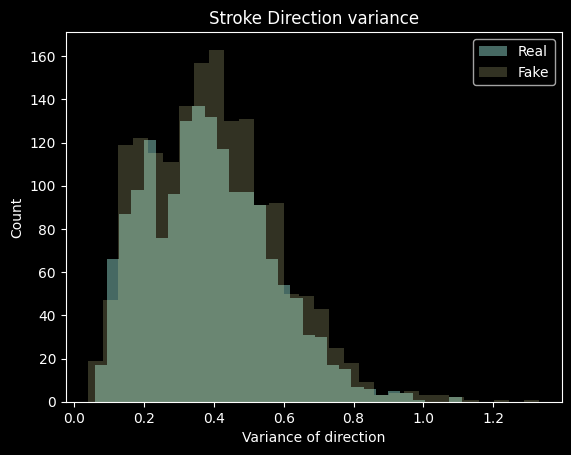

In [23]:
plt.hist(real_dir, bins=30, alpha=0.5, label="Real")
plt.hist(fake_dir, bins=30, alpha=0.2, label="Fake")
plt.legend()
plt.title("Stroke Direction variance")
plt.xlabel("Variance of direction")
plt.ylabel("Count")
plt.show()

### Total drawing time
Average drawing time is smaller for fake compared to real

In [24]:
def total_time(df):
    return df["time"].max() - df["time"].min()

real_time = [total_time(load_csv(f)) for f in real_files]
fake_time = [total_time(load_csv(f)) for f in fake_files]

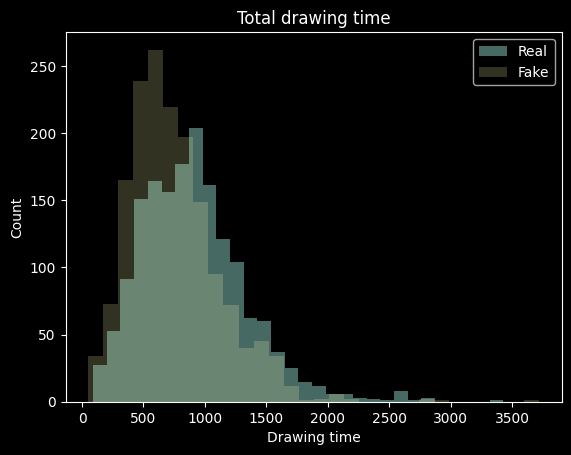

In [25]:
plt.hist(real_time, bins=30, alpha=0.5, label="Real")
plt.hist(fake_time, bins=30, alpha=0.2, label="Fake")
plt.legend()
plt.title("Total drawing time")
plt.xlabel("Drawing time")
plt.ylabel("Count")
plt.show()

### Bounding box sizes

In [26]:
def bbox_size(df):
    return (df["x"].max() - df["x"].min()) * (df["y"].max() - df["y"].min())

real_bbox = [bbox_size(load_csv(f)) for f in real_files]
fake_bbox = [bbox_size(load_csv(f)) for f in fake_files]

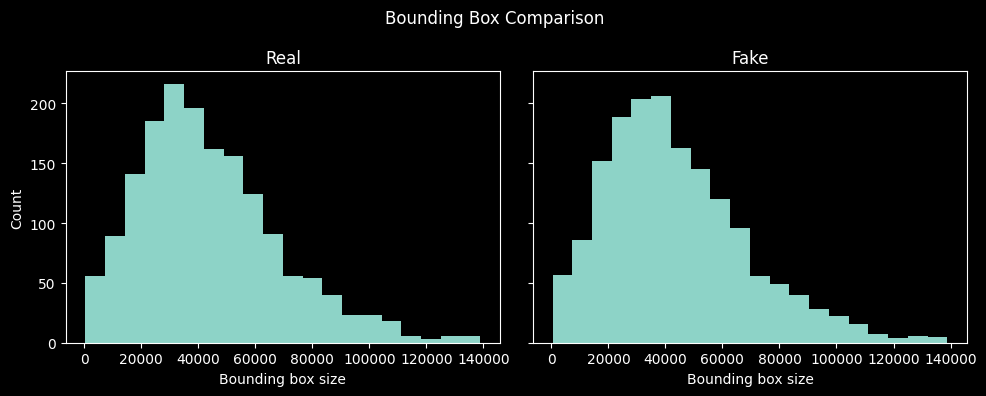

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# Real
axes[0].hist(real_bbox, bins=20)
axes[0].set_title("Real")
axes[0].set_xlabel("Bounding box size")
axes[0].set_ylabel("Count")

# Fake
axes[1].hist(fake_bbox, bins=20)
axes[1].set_title("Fake")
axes[1].set_xlabel("Bounding box size")

plt.suptitle("Bounding Box Comparison")
plt.tight_layout()
plt.show()

### Start-end distance

In [28]:
def start_end_dist(df):
    return np.sqrt(
        (df["x"].iloc[-1] - df["x"].iloc[0])**2 +
        (df["y"].iloc[-1] - df["y"].iloc[0])**2
    )

real_start_end_dist = [start_end_dist(load_csv(f)) for f in real_files]
fake_start_end_dist = [start_end_dist(load_csv(f)) for f in fake_files]

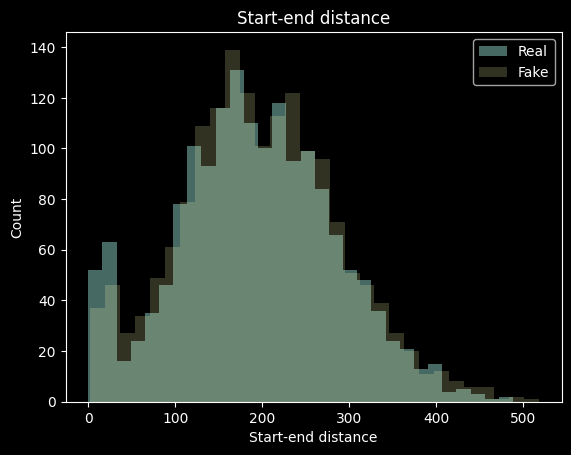

In [29]:
plt.hist(real_start_end_dist, bins=30, alpha=0.5, label="Real")
plt.hist(fake_start_end_dist, bins=30, alpha=0.2, label="Fake")
plt.legend()
plt.title("Start-end distance")
plt.xlabel("Start-end distance")
plt.ylabel("Count")
plt.show()

## Check distribution of input features

In [19]:
from train import read_sequence

DATA_DIR = "symbols"
SEQ_MAX_LEN = 512

seq_feature_names = [
    "dx",
    "dy",
    "r",
    "theta_sin",
    "theta_cos",
    "dtheta",
    "dt",
    "stroke_change",
    "curvature",
    "speed",
    "acceleration",
]

global_feature_names = [
    "has_large_dt",
    "length",
    "duration",
    "r_mean",
    "r_std",
    "dtheta_std",
]

items = []
for label_name, label in [("real", 0), ("fake", 1)]:
    for path in glob(os.path.join(DATA_DIR, label_name, "*.csv")):
        items.append((path, label_name))

seq_rows = []
global_rows = []

for path, label_name in items:
    seq, global_features = read_sequence(path, SEQ_MAX_LEN)

    df_seq = pd.DataFrame(seq, columns=seq_feature_names)
    df_seq["label"] = label_name
    df_seq["file"] = os.path.basename(path)
    seq_rows.append(df_seq)

    global_rows.append({
        "label": label_name,
        "file": os.path.basename(path),
        **dict(zip(global_feature_names, global_features))
    })

seq_df = pd.concat(seq_rows, ignore_index=True)
global_df = pd.DataFrame(global_rows)

print(seq_df.shape)
print(global_df.shape)

(249575, 13)
(3302, 8)


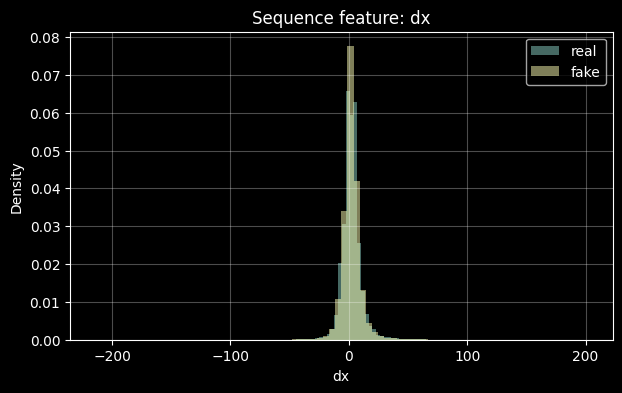

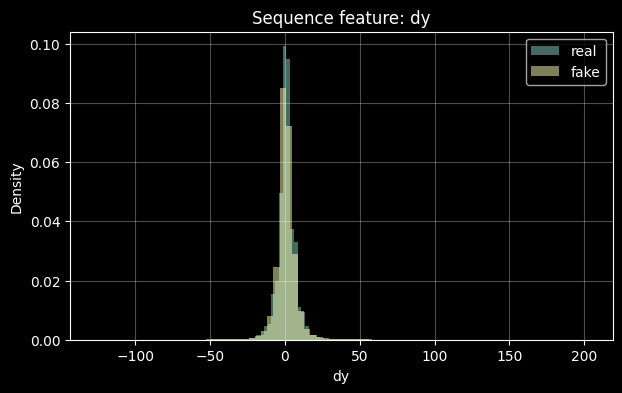

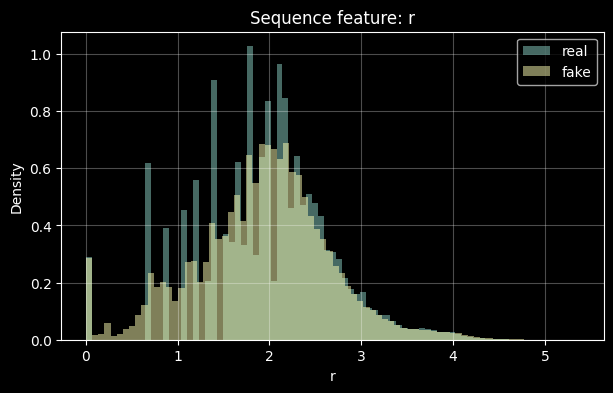

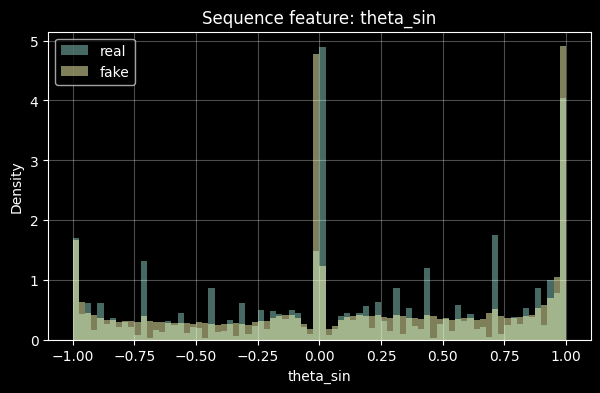

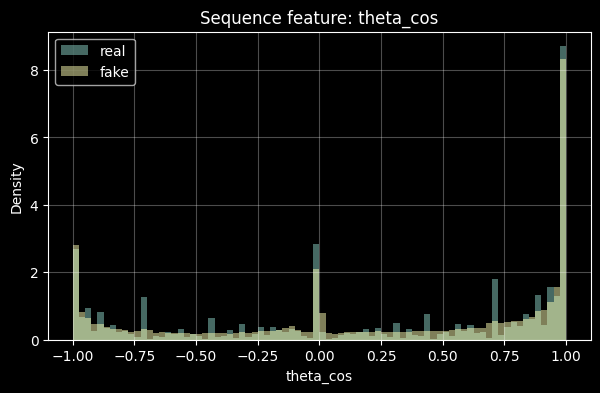

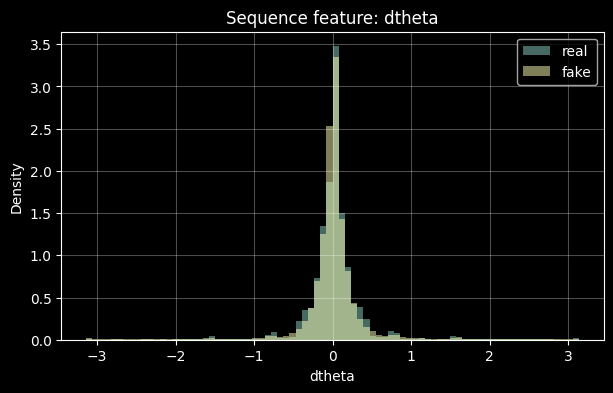

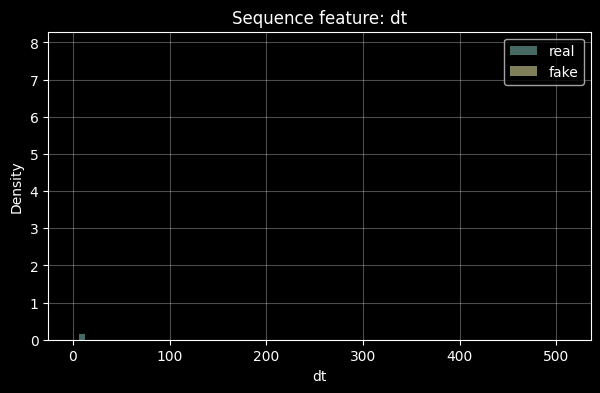

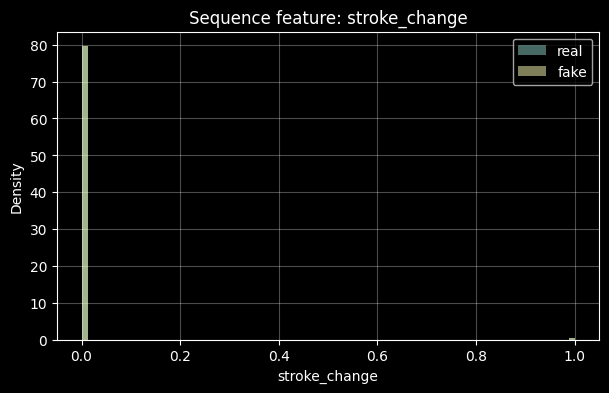

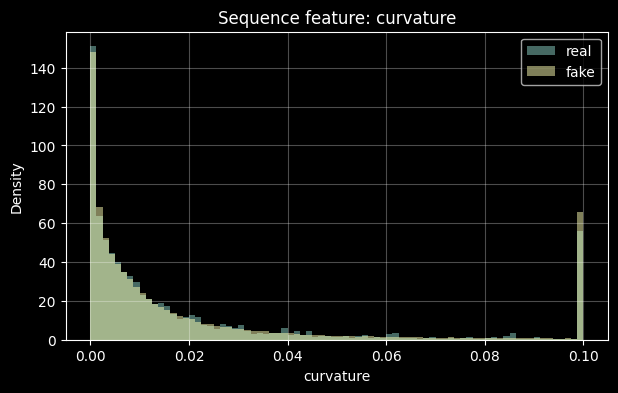

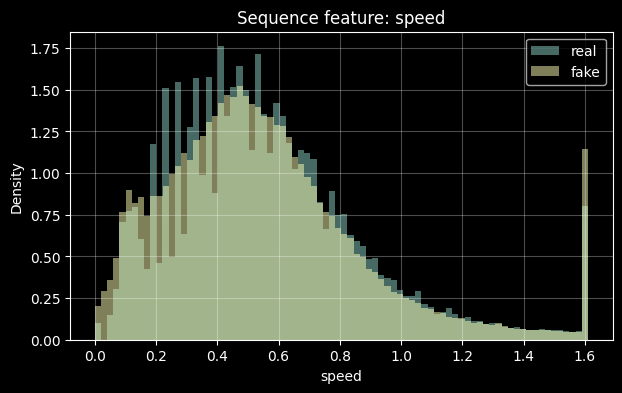

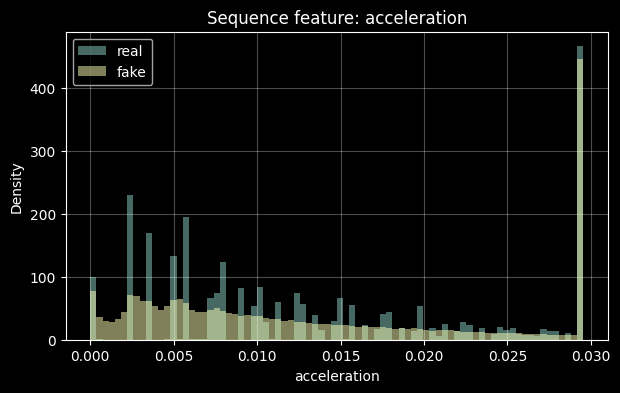

In [20]:
for col in seq_feature_names:
    plt.figure(figsize=(7, 4))

    for label_name in ["real", "fake"]:
        values = seq_df.loc[seq_df["label"] == label_name, col]
        plt.hist(values, bins=80, alpha=0.5, density=True, label=label_name)

    plt.title(f"Sequence feature: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
positive_features = ["speed", "curvature", "acceleration"]

for col in positive_features:
    plt.figure(figsize=(7, 4))

    for label_name in ["real", "fake"]:
        values = seq_df.loc[seq_df["label"] == label_name, col]
        values = np.log1p(values)
        plt.hist(values, bins=80, alpha=0.5, density=True, label=label_name)

    plt.title(f"log1p global feature: {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

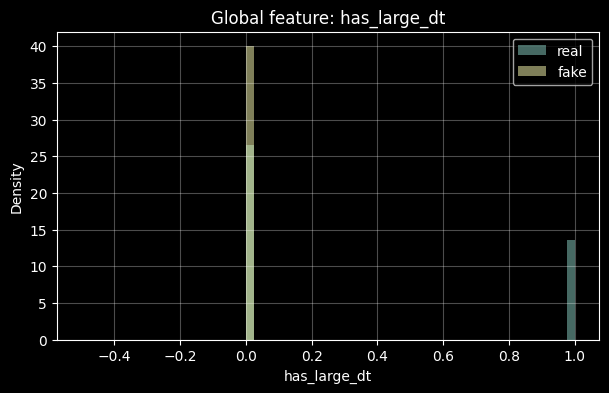

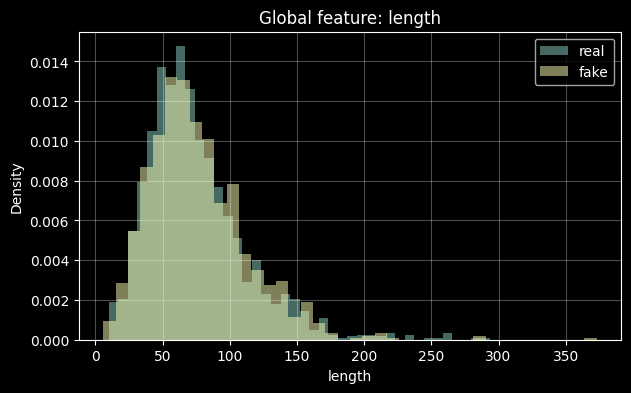

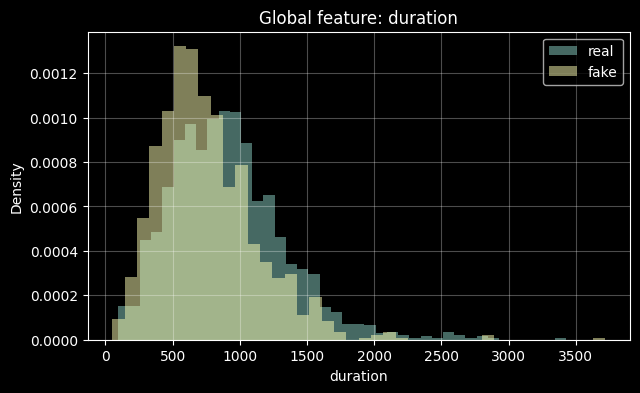

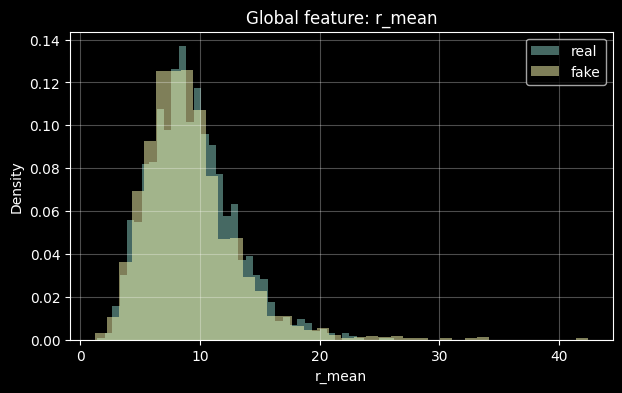

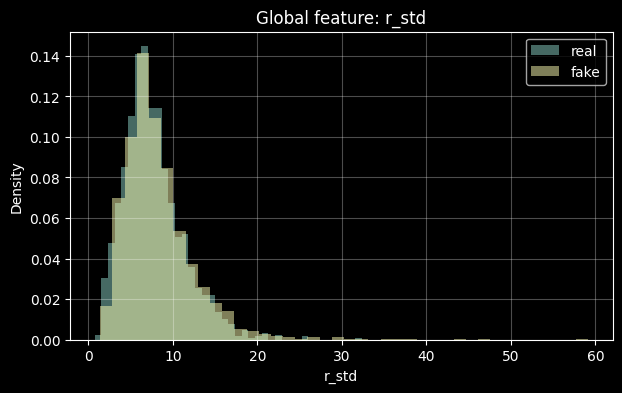

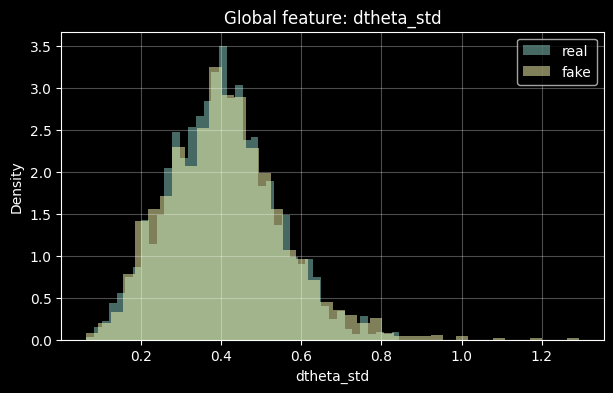

In [56]:
for col in global_feature_names:
    plt.figure(figsize=(7, 4))

    for label_name in ["real", "fake"]:
        values = global_df.loc[global_df["label"] == label_name, col]
        plt.hist(values, bins=40, alpha=0.5, density=True, label=label_name)

    plt.title(f"Global feature: {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

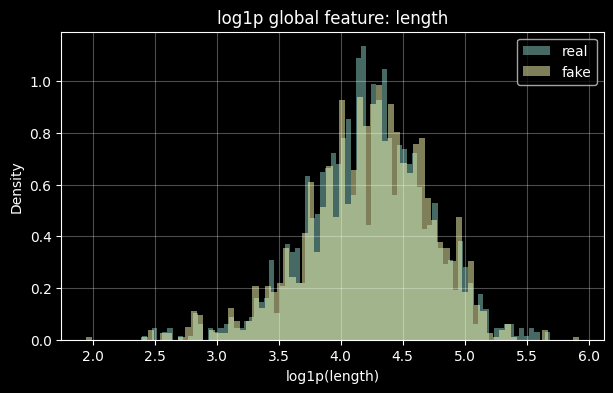

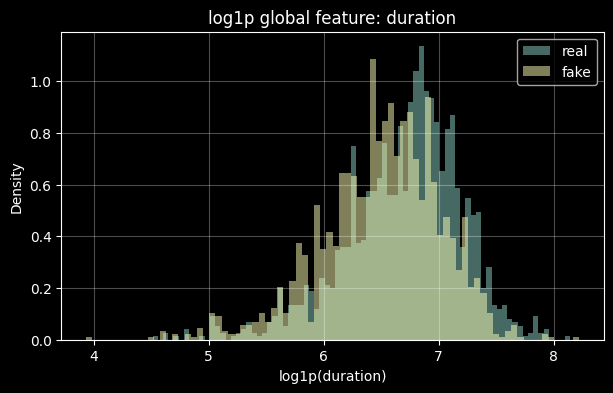

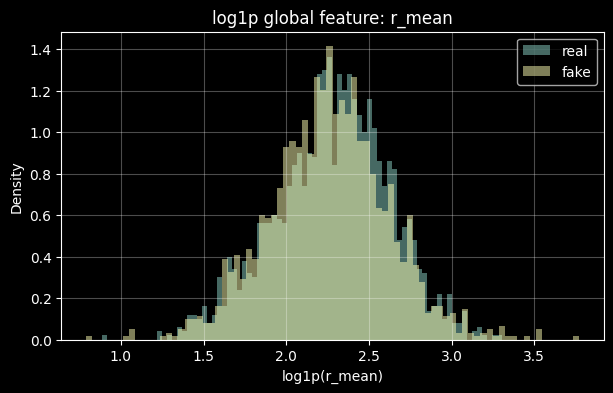

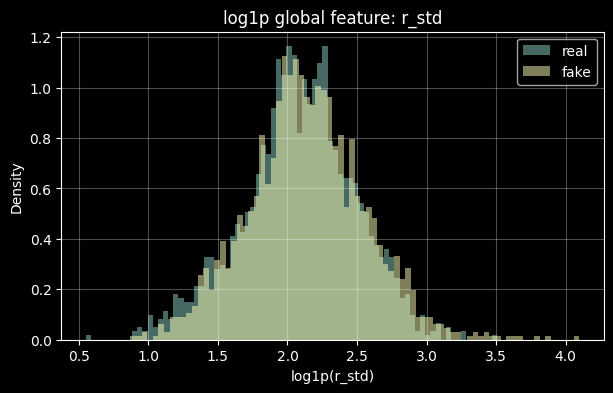

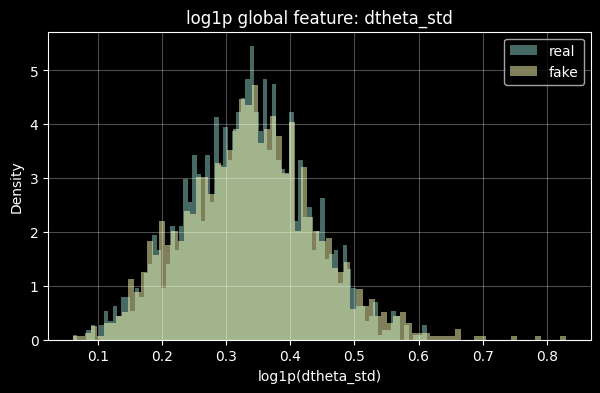

In [59]:
positive_features = ["length", "duration", "r_mean", "r_std", "dtheta_std"]

for col in positive_features:
    plt.figure(figsize=(7, 4))

    for label_name in ["real", "fake"]:
        values = global_df.loc[global_df["label"] == label_name, col]
        values = np.log1p(values)
        plt.hist(values, bins=80, alpha=0.5, density=True, label=label_name)

    plt.title(f"log1p global feature: {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Insights

- Drop stroke_id
- is_writing = 1 for all samples, so we can drop it
- time -> integer divided by 10
- Average length of dataframes of fakes is larger
    - Average drawing time is smaller for fakes than for real ones
- Average segment lengths for fakes is larger:
    - x and y -> Polar coordinates. Probably split theta into sin(theta), cos(theta)
- Looking at difference between time steps:
    - For real samples, there are some time steps >10ms, a lot with 510ms (always exactly 510ms for some reason, I don't know why). It happens between stroke ID's
    - For fakes, all time steps are 10ms
    - New feature: Time between stroke_transitions. If it is 510ms, you can be sure it is a real one (based on data set)
- Deep Fakes have a higher variability in direction changes -> Another reason for polar coordinates